<a href="https://colab.research.google.com/github/GianFor/Fondamenti_AI_Assignments/blob/main/Assignment_SymbolicAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GOFAI1**
Implementare (in Python) un agente che riceve i seguenti percept dall'ambiente ed effettua le seguenti azioni:
 - Percept: giorno per giorno (i) indicazione sulle condizioni atmosferiche (sereno, rischio pioggia, rischio neve), (ii) indicazione sul prezzo del carburante, (iii) distanza da percorrere (ad esempio, per andare a lavoro).
 - Azione: dato il percept giornaliero corrente, consigliare all'utente se effettuare il tragitto previsto giornaliero (ad esempio, per andare a lavoro) con la propria autovettura o mediante mezzi pubblici.
Le azioni dell'agente devono derivare dall'ottimizzazione di una misura di performance che tiene in considerazione la sicurezza stradale derivante dalle condizioni atmosferiche e il costo totale dello spostamento.

In [ ]:
import pandas as pd
import random
import matplotlib.pyplot as plt

##**Classe Percept**
Definisce la struttura dei Percept che l'agent si aspetta:

*   **Condizioni meteo**: $[sereno, pioggia, neve]$
*   **Prezzo carburante**: $^€/l$
*   **Distanza da percorrere**: $Km$




In [ ]:
class Percept:
  def __init__(self, condizioni, prezzo_carburante, distanza):
    self.condizioni = condizioni
    self.prezzo_carburante = prezzo_carburante
    self.distanza = distanza


## **Definizione dell'Agente Razionale (Utility-Based)**

L'agente implementato è un **Utility-Based Agent** progettato per ottimizzare la scelta del mezzo di trasporto basandosi su una misura di performance che bilancia efficienza economica e sicurezza stradale. L'agente opera secondo un modello di **razionalità limitata**, massimizzando la propria funzione di utilità in base ai parametri definiti nel proprio stato interno.

### **1. Modello di Calcolo dell'Utilità**

L'agente riceve un **percept** composto da: condizioni atmosferiche, prezzo del carburante e distanza. Per decidere l'azione, calcola l'utilità totale ($U_{tot}$) per ogni mezzo come somma pesata di due componenti normalizzate:

Dove: $U_{tot}=(w_{costo}*U_{costo})+(w_{sicurezza}*U_{sicurezza})$

* $U_{costo}$: Calcolata come $\frac{1}{1+Costo_€}$, trasformando il costo monetario in un valore di appagamento (più il costo è basso, più l'utilità tende a 1).
* $U_{sicurezza}$: Calcolata come complemento del rischio ($1-Rischio_{Meteo}$), dove il rischio dipende dalle condizioni atmosferiche.

---

### **2. Parametri Interni e Costi**

L'agente è inizializzato con una serie di parametri "hard-coded" che rappresentano la sua conoscenza del mondo e le sue preferenze simboliche:

#### **A. Componente Economica (Costi)**

| Parametro | Descrizione | Valore di Default |
| --- | --- | --- |
| **Consumo Auto** | Litri di carburante per chilometro | $0.07 l/km (ca. 14.3 km/l)$ |
| **Prezzo Base Mezzi** | Costo del biglietto per distanze $<10 Km$ | $1.50€$ |
| **Scatto Zona** | Supplemento ogni $10 Km$ aggiuntivi | $0.50€$ |

#### **B. Componente di Sicurezza (Fattori di Rischio)**

Il rischio è una variabile simbolica definita per ogni stato del percept "meteo":

| Condizione Meteo | Rischio Auto () | Rischio Mezzi () |
| --- | --- | --- |
| **Sereno** | $0.0$ | $0.05$ |
| **Pioggia** | $0.3$ | $0.05$ |
| **Neve** | $0.7$ | $0.05$ |

---

### **3. Meccanismo di Decisione (Action Selection)**

Dato il percept giornaliero, l'agente esegue la funzione `act()` che implementa la seguente logica:

1. **Percezione**: Acquisizione dei dati ambientali (Meteo, Prezzo Carburante, Distanza).
2. **Valutazione**: Calcolo del costo monetario effettivo per entrambi i mezzi.
3. **Ottimizzazione**: Calcolo dell'utilità pesata in base ai pesi $w_{costo}$ (es. $0.6$) e $w_{rischio}$ (es. $0.4$).
4. **Azione**: Selezione del mezzo con l'utilità maggiore:


In [ ]:
class Agent:
  def __init__(self, w_costo=0.6, w_sicurezza=0.4):
    #PESI RELATIVI A COSTO E SICUREZZA DEL SPOSTAMENTO
    self.w_costo = w_costo  #il peso che l'agent attribuisce al costo dello spostamento
    self.w_sicurezza = w_sicurezza  #il peso che l'agent attribuisce alla sicurezza dello spostamento

    #PARAMETRI RELATIVI AI COSTI
    self.consumo_auto = 0.07 #litri per ogni km (circa 14.3 km/l)

    self.costo_base_biglietto_mezzi = 1.5 #euro per i primi 10km
    self.scatto_zona = 0.50  # ogni 10km il prezzo sale di 50 cent
    self.km_per_zona = 10


    #PESI RELATIVI AI RISCHI PER CONDIZIONI METEO
    self.rischio_auto = {  #dizionario che contiene il rischio di andare in auto con determinate condizioni meteo
        "sereno" : 0,
        "pioggia" : 0.3,
        "neve" : 0.7
    }

    self.rischio_mezzi = 0.05 #lo spostamento coi mezzi ha sempre un rischio basso, a prescindere dalle condizioni meteo



  def set_percept(self, p: Percept):  #l'agente ottiene i percept del giorno tramite un oggetto Percept
    self.percept = p

  def _calcola_prezzo_biglietto(self):
    #CALCOLO DEL PREZZO DEL BIGLIETTO PER I MEZZI
    zone_extra = self.percept.distanza // self.km_per_zona
    return self.costo_base_biglietto_mezzi + (zone_extra * self.scatto_zona)

  def _calcola_prezzo_auto(self):
    #CALCOLO DEL PREZZO DEL VIAGGIO IN AUTO
    return self.percept.distanza * self.consumo_auto * self.percept.prezzo_carburante


  def act(self):
    # 1. Calcolo dei costi monetari grezzi
    c_auto_euro = self._calcola_prezzo_auto()
    c_mezzi_euro = self._calcola_prezzo_biglietto()

    # 2. Normalizzazione del COSTO (usando la tua formula U = 1 / (1 + C))
    # Più il costo è alto, più l'utilità si avvicina a 0
    u_costo_auto = 1 / (1 + c_auto_euro)
    u_costo_mezzi = 1 / (1 + c_mezzi_euro)

    # 3. Trasformazione del RISCHIO in SICUREZZA (Utilità)
    # Dato che il rischio è 0.7 (male), la sicurezza sarà 1 - 0.7 = 0.3 (bene)
    u_sicurezza_auto = 1 - self.rischio_auto[self.percept.condizioni]
    u_sicurezza_mezzi = 1 - self.rischio_mezzi

    # 4. Calcolo dell'Utilità Totale (Weighted Sum)
    # Ora sommiamo Valori tra 0 e 1 con Valori tra 0 e 1. Matematicamente perfetto.
    utilita_auto = (u_costo_auto * self.w_costo) + (u_sicurezza_auto * self.w_sicurezza)
    utilita_mezzi = (u_costo_mezzi * self.w_costo) + (u_sicurezza_mezzi * self.w_sicurezza)

    # 5. Decisione basata sull'utilità MAGGIORE (massimizzazione della performance)
    if utilita_auto >= utilita_mezzi:
      return "auto"
    else:
      return "mezzi"



## **Classe Simulation (L'Ambiente)**

La classe `Simulation` funge da **Environment** (Ambiente), rappresentando il mondo dinamico in cui l'agente opera e con cui interagisce per un arco temporale definito. Il suo compito principale è quello di modellare l'incertezza e la variabilità del mondo reale attraverso la generazione di dati stocastici (casuali), fornendo all'agente una sequenza coerente di **percept** (percezioni).

### **Generazione dei Percept**
Ogni giorno della simulazione, la classe genera tre variabili fondamentali che determinano il contesto decisionale:

| Dato | Scelta | Range / Distribuzione |
| --- | --- | --- |
| **Meteo** | Random pesata | $w_{sereno} = 0.7, w_{pioggia} = 0.2, w_{neve} = 0.1$ |
| **Prezzo Carburante** | Random float | $[1.70 - 2.00] €/l$ |
| **Distanza** | Random int | $[5 - 50] km$ |

---

### **Il Ciclo di Simulazione (Simulate Loop)**
Il funzionamento segue l'architettura classica dell'IA simbolica:

1. **Inizializzazione del Mondo**: Vengono pre-generati i dati ambientali per $30$ giorni per garantire che diverse configurazioni di agenti possano essere testate a parità di condizioni (esperimento controllato).
2. **Ciclo Percezione-Azione**: Per ogni passo temporale (giorno), l'ambiente fornisce il percept corrente all'agente.
3. **Esecuzione dell'Azione**: L'agente analizza i dati, calcola l'utilità e restituisce la scelta del mezzo di trasporto.
4. **Aggiornamento e Log**: L'ambiente registra la scelta dell'agente e calcola le metriche di performance reali (costo effettivo e rischio accumulato), aggiornando la propria "storia" interna per le analisi finali.

Questa struttura permette di valutare quantitativamente l'efficacia delle euristiche dell'agente e la sua capacità di ottimizzare la misura di performance su un periodo prolungato.

In [ ]:
class Simulation:
    def __init__(self, days=30):
        self.days = days
        # Generiamo i dati del mondo per 30 giorni (uguali per tutti i test)
        self.world_data = []
        for _ in range(days):
            self.world_data.append({
                "meteo": random.choices(["sereno", "pioggia", "neve"], weights=[0.7, 0.2, 0.1])[0], # generazione pesata del meteo (sole è priritizzato)
                "prezzo": round(random.uniform(1.70, 2.00), 2),
                "distanza": random.randint(5, 50)
            })

    def run_agent(self, agent):
        results = []
        for i, day in enumerate(self.world_data):
            p = Percept(day['meteo'], day['prezzo'], day['distanza'])
            agent.set_percept(p)
            scelta = agent.act()

            # Calcolo metriche reali per l'analisi
            costo = agent._calcola_prezzo_auto() if scelta == "auto" else agent._calcola_prezzo_biglietto()
            rischio = agent.rischio_auto[day['meteo']] if scelta == "auto" else agent.rischio_mezzi

            results.append({
                "Giorno": i+1, "Meteo": day['meteo'], "Prezzo": day['prezzo'], "Dist": day['distanza'],
                "Scelta": scelta, "Costo": costo, "Rischio": rischio
            })
        return pd.DataFrame(results)

## **Classe ViaggioVisualizer: Analisi e Display**
La classe `ViaggioVisualizer` è responsabile del tracciamento e della visualizzazione dei risultati, permettendo di interpretare la logica decisionale dell'agente attraverso la cronologia dei dati.

1. **Dashboard dell'Ambiente (Percept History)**
Visualizza la cronologia degli input ambientali (distanza e prezzo), similmente a come vengono tracciate le sequenze di percept di prezzo e scorte negli esempi classici. Questo grafico permette di osservare la "pressione" esterna a cui l'agente è sottoposto.


2. **Logica Decisionale (Action History)**
Rappresenta graficamente la sequenza di azioni intraprese dall'agente. L'uso di grafici "step" allineati con uno sfondo colorato (meteo) serve a validare visivamente se l'agente sta rispettando i pesi di sicurezza e costo impostati al variare delle condizioni atmosferiche.

3. **Performance e Trade-off**
Confronta l'efficienza degli agenti analizzando il trade-off tra spesa economica e rischio accumulato. Questa analisi quantitativa dimostra come la variazione dei pesi interni modifichi radicalmente il comportamento "razionale" del sistema intelligente nel raggiungere i propri obiettivi di performance.

In [ ]:
class ViaggioVisualizer:
    def __init__(self, data_safe, data_money):
        self.df_safe = data_safe
        self.df_money = data_money
        # Colori simbolici per il meteo (Sfondo)
        self.meteo_colors = {'sereno': '#FFF9C4', 'pioggia': '#BBDEFB', 'neve': '#E1F5FE'}

    def plot_environment_story(self):
        """
        Dashboard degli Input (Percepts): Racconta cosa succede nel mondo.
        Mostra Distanza e Prezzo su assi condivisi.
        """
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        giorni = self.df_safe['Giorno']

        # 1. Distanza (Barre per indicare la variabilità del tragitto)
        ax1.bar(giorni, self.df_safe['Dist'], color='gray', alpha=0.3, label='Distanza Giornaliera (km)')
        ax1.set_ylabel("Chilometri (km)")
        ax1.set_title("Ambiente di Simulazione: Variabili Esterne")
        ax1.legend(loc="upper left")
        ax1.grid(axis='y', linestyle='--', alpha=0.5)

        # 2. Prezzo Carburante (Linea per indicare il trend economico)
        ax2.plot(giorni, self.df_safe['Prezzo'], color='darkgreen', marker='o', markersize=4, label='Prezzo Carburante (€/l)')
        ax2.set_ylabel("Prezzo (€/l)")
        ax2.set_ylim(1.6, 2.1)
        ax2.legend(loc="upper left")
        ax2.grid(True, linestyle='--', alpha=0.5)

        plt.xlabel("Giorno")
        plt.tight_layout()
        plt.show()

    def plot_decision_logic(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        giorni = self.df_safe['Giorno']

        safe_choices = self.df_safe['Scelta'].map({'auto': 1, 'mezzi': 0})
        money_choices = self.df_money['Scelta'].map({'auto': 1, 'mezzi': 0})

        ax1.step(giorni, safe_choices, where='mid', color='green', linewidth=2.5, label='Agente Sicuro')
        ax2.step(giorni, money_choices, where='mid', color='blue', linewidth=2.5, label='Agente Economo')

        for ax in [ax1, ax2]:
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['MEZZI', 'AUTO'])
            ax.set_ylabel("Decisione")
            ax.set_xlim(giorni.min() - 0.5, giorni.max() + 0.5) # Centra l'asse X

            # Allineamento sfondo meteo
            for i in range(len(self.df_safe)):
                meteo = self.df_safe.iloc[i]['Meteo']
                # Lo sfondo ora copre esattamente da -0.5 a +0.5 del giorno centrale
                ax.axvspan(giorni.iloc[i]-0.5, giorni.iloc[i]+0.5,
                           color=self.meteo_colors.get(meteo, 'white'), alpha=0.4, zorder=-1)

        ax1.set_title("Logica Decisionale: Agente SICUREZZA")
        ax2.set_title("Logica Decisionale: Agente RISPARMIO")
        plt.xlabel("Giorno (Giallo=Sereno, Blu=Pioggia, Azzurro=Neve)")
        plt.tight_layout()
        plt.show()

    def plot_tradeoff_performance(self):
        """
        Analisi della Misura di Performance: Mostra il compromesso (Trade-off).
        A sinistra la spesa economica, a destra il rischio cumulativo.
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        giorni = self.df_safe['Giorno']

        # Metrica Economica: Spesa Cumulata
        ax1.plot(giorni, self.df_safe['Costo'].cumsum(), label='Agente Sicuro', color='green', linewidth=2)
        ax1.plot(giorni, self.df_money['Costo'].cumsum(), label='Agente Economo', color='blue', linewidth=2)
        ax1.set_title("Efficienza Economica: Costo Totale Accumulato")
        ax1.set_ylabel("Spesa (€)")
        ax1.legend()
        ax1.grid(True)

        # Metrica di Sicurezza: Rischio Cumulato
        # Rappresenta quanto 'pericolo' ha accumulato l'utente seguendo i consigli
        ax2.plot(giorni, self.df_safe['Rischio'].cumsum(), label='Agente Sicuro', color='green', linestyle='--')
        ax2.plot(giorni, self.df_money['Rischio'].cumsum(), label='Agente Economo', color='blue', linestyle='--')
        ax2.set_title("Efficienza Sicurezza: Rischio Totale Accumulato")
        ax2.set_ylabel("Rischio (Somma indici)")
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

## **Confronto delle Performance: Agente Sicuro vs Agente Economo**

In questa sezione finale, viene orchestrato l'esperimento. Vengono messi a confronto due agenti con priorità opposte:
1. **Agente Sicuro**: Pesa maggiormente la sicurezza stradale ($w_{sicurezza}=0.8$).
2. **Agente Economo**: Pesa maggiormente il risparmio economico ($w_{costo}=0.8$).

Attraverso la stampa delle metriche finali (Spesa Totale e Rischio Medio), validiamo l'efficacia della funzione di utilità. I risultati mostrano come l'agente sia in grado di adattare le proprie decisioni per servire al meglio l'obiettivo di performance impostato, dimostrando la flessibilità della logica simbolica rispetto a condizioni ambientali variabili.

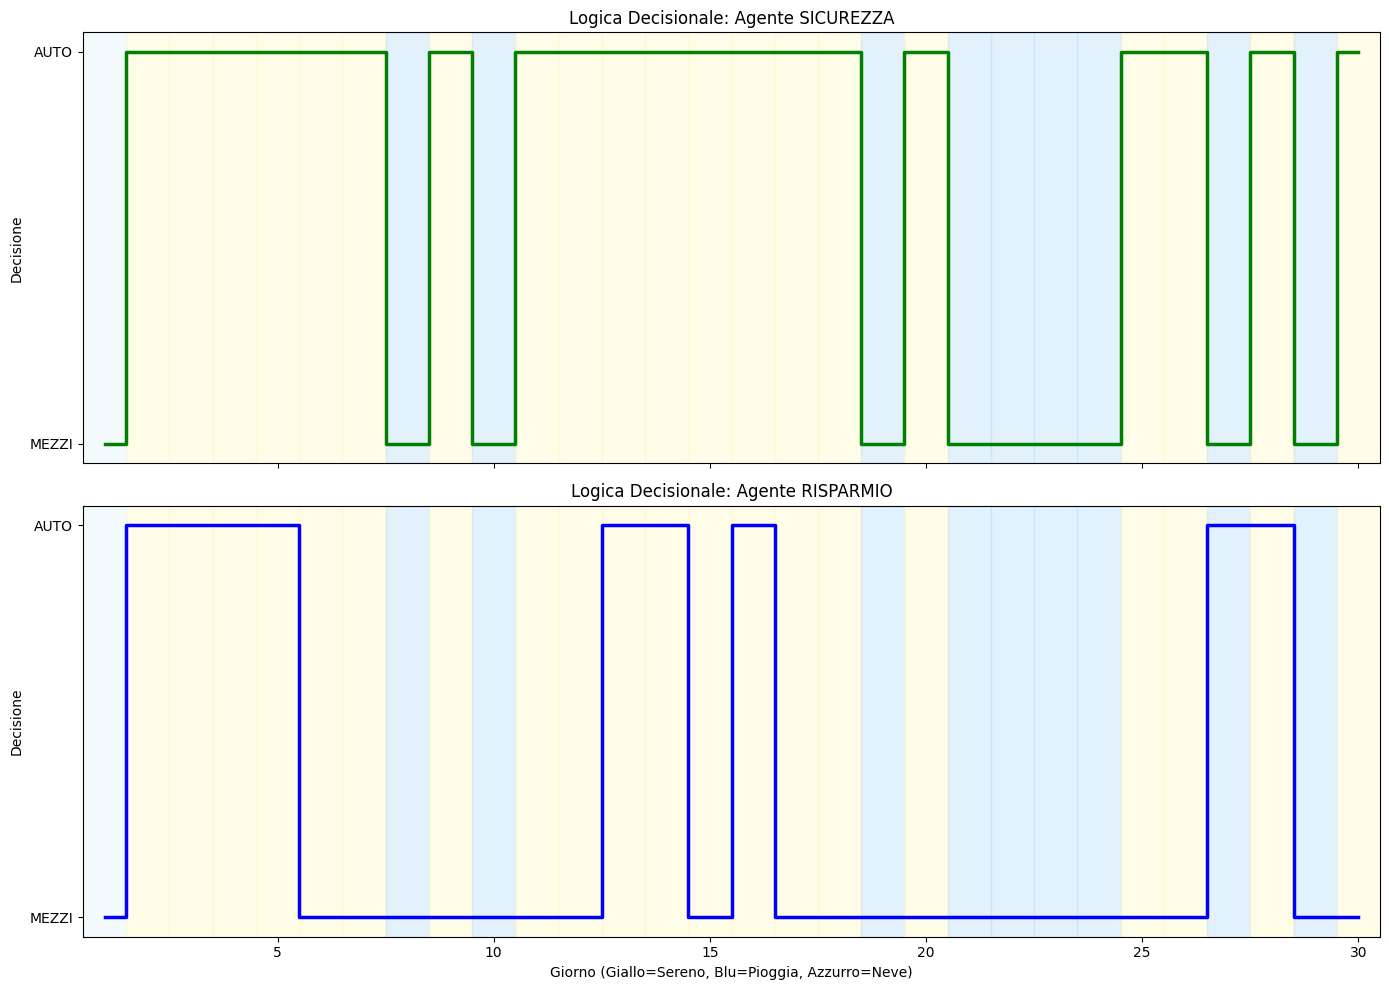

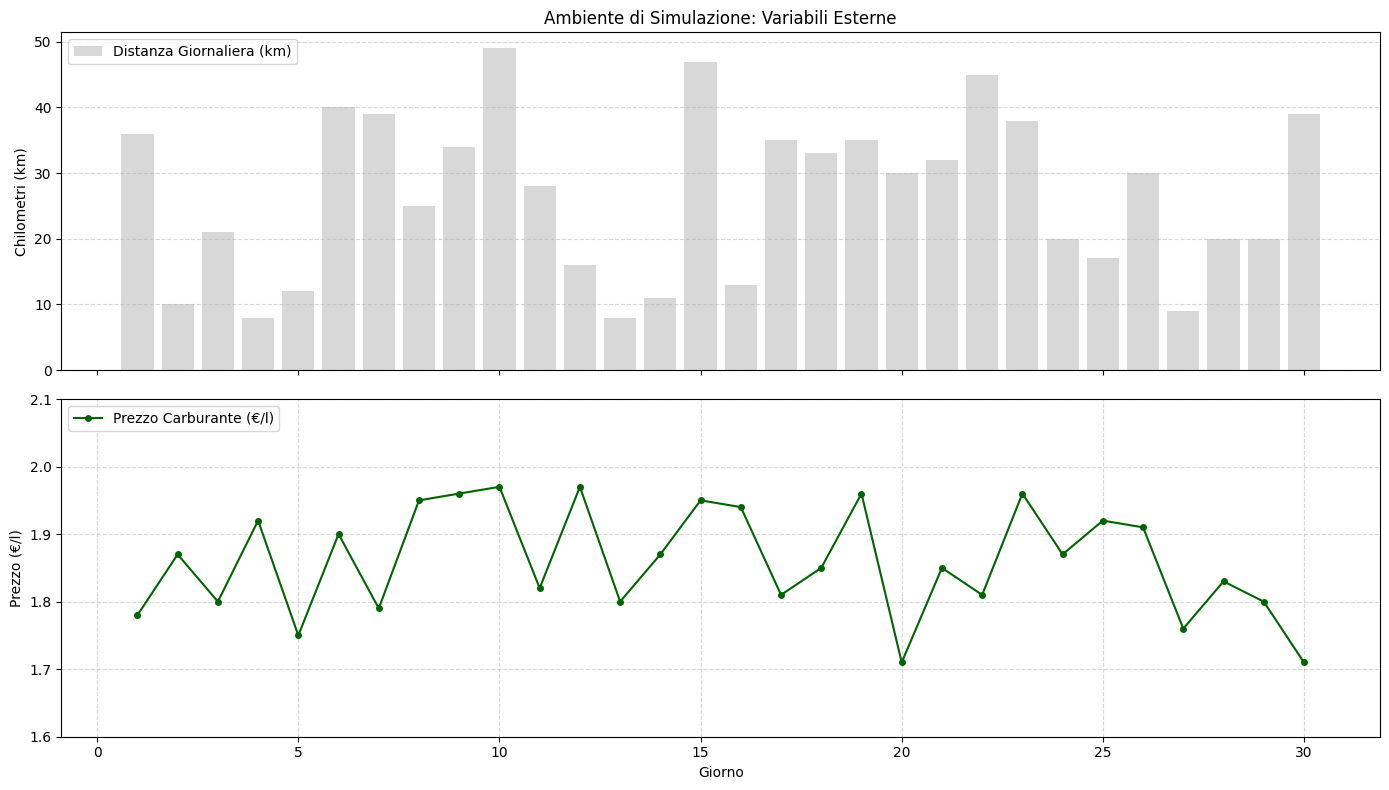

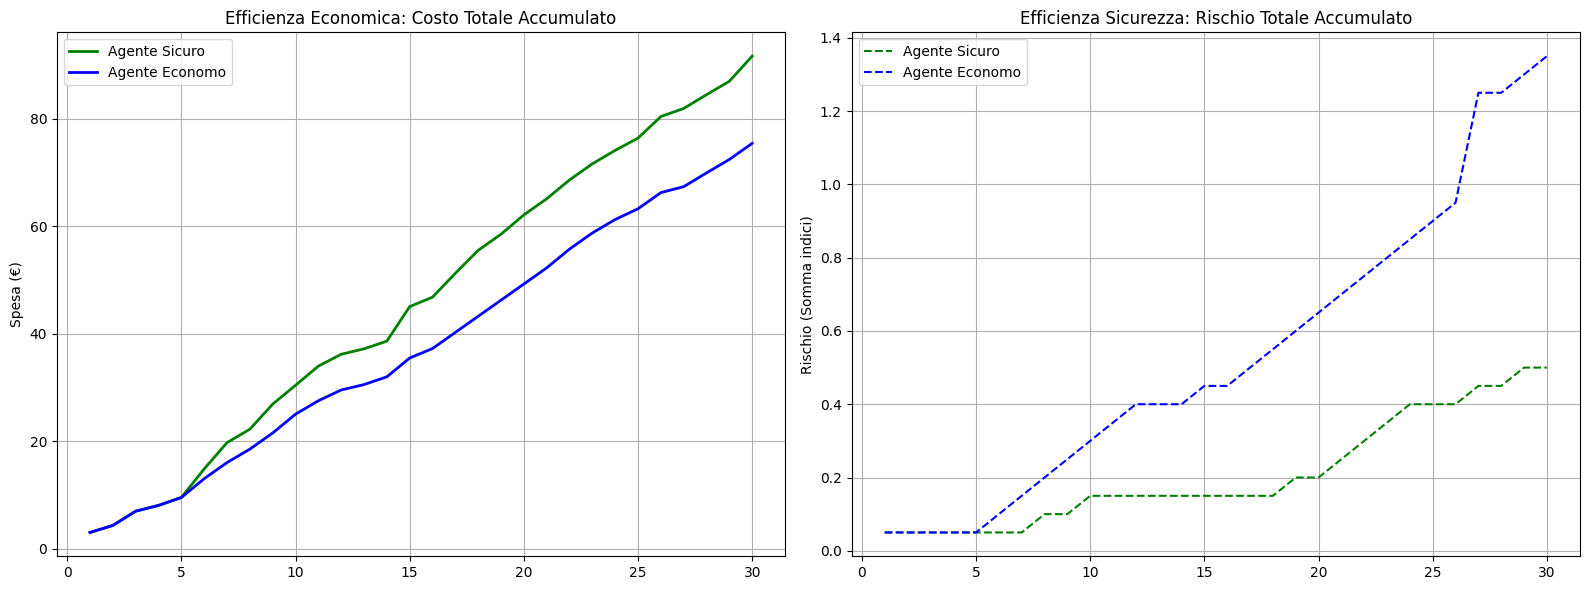

ANALISI PERFORMANCE (30 GIORNI)
-----------------------------------
AGENTE SICURO  -> Spesa: 91.60€ | Rischio Medio: 0.017
AGENTE ECONOMO -> Spesa: 75.38€ | Rischio Medio: 0.045


In [ ]:
sim = Simulation(days=30)

# Agente A: Priorità Sicurezza
agente_safe = Agent(w_costo=0.2, w_sicurezza=0.8)
res_safe = sim.run_agent(agente_safe)

# Agente B: Priorità Risparmio
agente_money = Agent(w_costo=0.8, w_sicurezza=0.2)
res_money = sim.run_agent(agente_money)

visualizer = ViaggioVisualizer(res_safe, res_money)
visualizer.plot_decision_logic()
visualizer.plot_environment_story()
visualizer.plot_tradeoff_performance()

# --- RISULTATI ---
print(f"ANALISI PERFORMANCE (30 GIORNI)\n" + "-"*35)
print(f"AGENTE SICURO  -> Spesa: {res_safe['Costo'].sum():.2f}€ | Rischio Medio: {res_safe['Rischio'].mean():.3f}")
print(f"AGENTE ECONOMO -> Spesa: {res_money['Costo'].sum():.2f}€ | Rischio Medio: {res_money['Rischio'].mean():.3f}")

# **Conclusioni**

L'obiettivo di questo progetto era l'implementazione di un agente razionale di tipo **GOFAI (Good Old Fashioned AI)** capace di ottimizzare le scelte di trasporto quotidiane basandosi su una funzione di utilità simbolica. Attraverso la simulazione di 30 giorni e il confronto tra diverse configurazioni, è stato possibile trarre le seguenti conclusioni.

### **1. Validazione della Razionalità dell'Agente**
L'esperimento ha dimostrato che l'agente si comporta in modo strettamente razionale rispetto ai pesi di utilità impostati:
- **Agente Orientato alla Sicurezza ($w_{s}=0.8$):** Ha mostrato una drastica riduzione del rischio medio giornaliero. Le visualizzazioni confermano che l'agente sceglie sistematicamente i mezzi pubblici non appena le condizioni atmosferiche peggiorano (pioggia o neve), accettando una spesa economica totale superiore.
- **Agente Orientato al Risparmio ($w_{c}=0.8$):** Ha ottenuto una spesa cumulativa sensibilmente inferiore. Tuttavia, la sua "razionalità economica" lo ha spinto a utilizzare l'auto anche in condizioni di rischio moderato, con un conseguente aumento del valore di rischio medio accumulato.

### **2. Analisi del Trade-off (Costo vs Sicurezza)**
I grafici delle performance accumulate evidenziano chiaramente il **compromesso** intrinseco nel sistema:
- Non esiste una scelta "ottima" in assoluto, ma solo una scelta ottimale rispetto alla funzione di performance definita.
- La Symbolic AI permette di rendere queste decisioni **trasparenti e spiegabili**: ogni "salto" nel grafico delle decisioni è direttamente riconducibile a un valore numerico nel percept (es. un picco di prezzo o un cambio di meteo) elaborato attraverso i pesi dell'agente.

### **3. Considerazioni sulla GOFAI**
Questo progetto illustra i punti di forza dell'intelligenza artificiale simbolica:
- **Prevedibilità**: Il comportamento dell'agente è deterministico e basato su regole logico-matematiche esplicite.
- **Modellabilità**: È stato possibile cambiare radicalmente la "personalità" dell'agente semplicemente modificando i pesi simbolici, senza necessità di nuovo addestramento.
- **Tracciabilità**: Grazie alla struttura Ambiente-Agente, ogni azione è motivata da una chiara massimizzazione dell'utilità calcolata su dati certi (percept).

In conclusione, l'agente implementato soddisfa pienamente i requisiti di ottimizzazione richiesti, dimostrando come un sistema basato su regole e funzioni di utilità possa gestire efficacemente processi decisionali complessi in ambienti dinamici e stocastici.